In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from keras.applications import InceptionV3
from tensorflow.keras.datasets import cifar10 as cf
from tensorflow.keras.utils import to_categorical


In [3]:
(x_train, y_train), (x_test, y_test) = cf.load_data()

In [17]:
print(x_train.shape)
print(y_train.shape)
print(y_test.shape)
print(x_test.shape)


(50000, 32, 32, 3)
(50000, 10)
(10000, 10)
(10000, 32, 32, 3)


In [5]:
x_train = x_train/255.0
x_test = x_test/255.0

In [6]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [8]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

87910968/87910968 [==============================] - 11s 0us/step


In [9]:
# freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
'''
Alternate Method
'''

In [10]:
# Build the model
model = Sequential()

#define the input shape
model.add(layers.UpSampling2D(size=(3, 3), interpolation='bilinear')) # Resize 32x32 to 96x96

# Add the VGG16 base model
model.add(base_model)

#Flatten / Pool the output from VGG16's convolutional layers
# model.add(Flatten()) # this is the original method
model.add(GlobalAveragePooling2D())

#Add a fully connected layer with 256 units and ReLU activation
model.add(Dense(512, activation='relu'))

#Add a dropout layer with a dropout rate of 0.5 for regularization
model.add(Dropout(0.5))

# Add output layer with 10 units (for 10 classes) and softmax activation
model.add(Dense(10, activation='softmax'))

#Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])



In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 up_sampling2d (UpSampling2  (None, 96, 96, 3)         0         
 D)                                                              
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 up_sampling2d (UpSampling2  (None, 96, 96, 3)         0         
 D)                                                              
                                                                 
 inception_v3 (Functional)   (None, 1, 1, 2048)        21802784  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 512)               1

In [11]:
history = model.fit(x_train, y_train, epochs=3, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/3


782/782 [==============================] - 84s 103ms/step - loss: 1.2734 - accuracy: 0.5690 - val_loss: 1.0065 - val_accuracy: 0.6576
Epoch 2/3
782/782 [==============================] - 93s 120ms/step - loss: 1.0432 - accuracy: 0.6399 - val_loss: 0.9593 - val_accuracy: 0.6717
Epoch 3/3
782/782 [==============================] - 106s 135ms/step - loss: 0.9784 - accuracy: 0.6599 - val_loss: 0.9502 - val_accuracy: 0.6728


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 2)
print('Test accuracy:', test_acc)

313/313 - 20s - loss: 1.2060 - accuracy: 0.5780 - 20s/epoch - 63ms/step
Test accuracy: 0.578000009059906


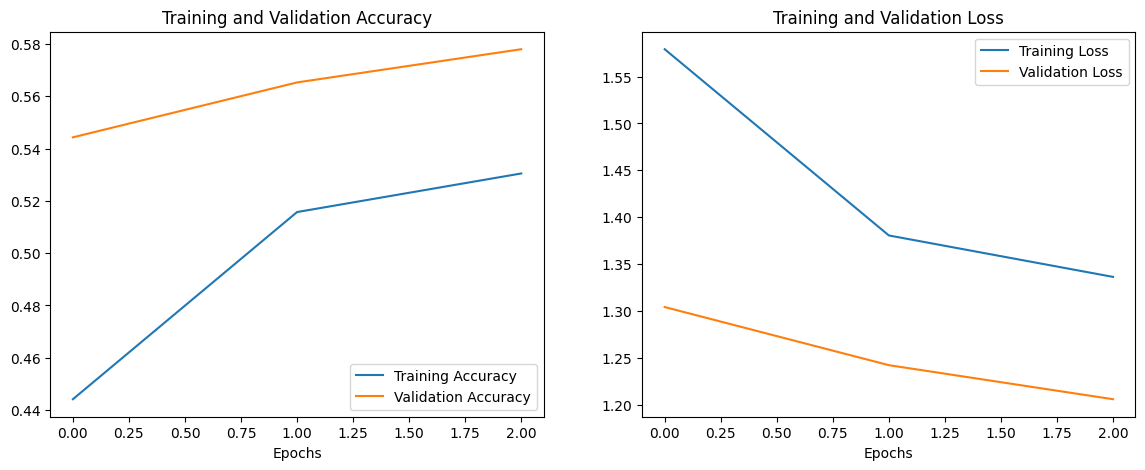

In [ ]:
# plotting the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.legend(loc = 'lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc = 'upper right')
plt.show()
